<a href="https://colab.research.google.com/github/cu24250216-oss/Computer-Vision-Experiments/blob/main/TANISHASINGH_60_EXPERIMENT07_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LABSHEET 10**

**Motion Estimation using Optical Flow Algorithms in** **Video Sequences**

In [7]:
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()
video_path = list(uploaded.keys())[0]

print("Video uploaded:", video_path)

Saving Screenshot 2026-03-15 222211.png to Screenshot 2026-03-15 222211.png
Video uploaded: Screenshot 2026-03-15 222211.png


In [9]:
cap = cv2.VideoCapture(video_path)

ret, old_frame = cap.read()

if not ret:
    print("Video could not be read")
else:
    old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

    p0 = cv2.goodFeaturesToTrack(
        old_gray, maxCorners=100,
        qualityLevel=0.3, minDistance=7
    )

    for i in range(30):
        ret, frame = cap.read()

        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        p1, status, error = cv2.calcOpticalFlowPyrLK(
            old_gray, gray, p0, None
        )

        if p1 is None:
            break

        good_new = p1[status == 1]
        good_old = p0[status == 1]

        for new, old in zip(good_new, good_old):
            x1, y1 = new.ravel().astype(int)
            x2, y2 = old.ravel().astype(int)

            cv2.arrowedLine(frame, (x2, y2), (x1, y1),
                            (0, 255, 0), 2)

        cv2_imshow(frame)

        old_gray = gray.copy()
        p0 = good_new.reshape(-1, 1, 2)

In [10]:
cap = cv2.VideoCapture(video_path)

ret, old_frame = cap.read()

if not ret:
    print("Video could not be read")
else:
    old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

    for i in range(10):
        ret, frame = cap.read()

        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        flow = cv2.calcOpticalFlowFarneback(
            old_gray, gray, None,
            0.5, 3, 15, 3, 5, 1.2, 0
        )

        mag, ang = cv2.cartToPolar(
            flow[..., 0], flow[..., 1]
        )

        hsv = np.zeros_like(frame)
        hsv[..., 1] = 255
        hsv[..., 0] = ang * 90 / np.pi
        hsv[..., 2] = cv2.normalize(
            mag, None, 0, 255, cv2.NORM_MINMAX
        )

        result = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

        cv2_imshow(result)

        old_gray = gray.copy()

Video opened: True
Frame read: True
Frame size: (312, 507, 3)


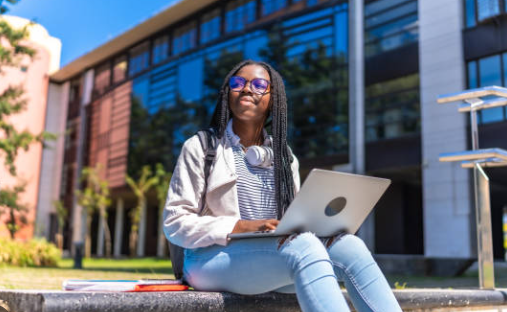

In [11]:
cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()

print("Video opened:", cap.isOpened())
print("Frame read:", ret)

if ret:
    print("Frame size:", frame.shape)
    cv2_imshow(frame)

**QUESTIONS **

Q1. What is Optical Flow?
Optical Flow is the apparent motion of pixels between two consecutive video frames. It is used for motion detection and tracking.

Q2. Working principle of Lucas-Kanade?
It tracks selected feature points between two frames and calculates their movement.

Q3. What is Dense Optical Flow?
It calculates motion for almost every pixel in an image.

Q4. Lucas-Kanade vs Farneback?
Lucas-Kanade is sparse and faster, while Farneback is dense and more computationally expensive.

Q5. Assumptions of Optical Flow?

Constant brightness
Small motion
Similar motion of neighboring pixels

Q6. Factors affecting accuracy?
Noise, lighting changes, fast motion, occlusion, and motion blur.

Q7. Five applications?

Object tracking
Autonomous driving
Video surveillance
Motion detection
Robot navigation

Q8. Why use grayscale images?
Grayscale reduces computation and provides useful intensity information for motion estimation.

Q9. Limitations of Optical Flow?
It can be affected by noise, illumination changes, occlusion, fast motion, and low-texture areas.

Q10. Role in real-world applications?
Optical flow helps detect and track movement in autonomous vehicles, surveillance systems, and action recognition.